# Experiment setup and paths
Build paths and optional loaders used by the metric computation cells.

Scenarios: ['clasp_factoring', 'saps-CVVAR', 'spear_qcp', 'yalsat_qcp', 'spear_swgcp', 'yalsat_swgcp', 'lpg-zeno']
Context sizes: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
Models: ['tabpfn', 'distnet', 'lognormal_naive', 'tabpfn_naive', 'random_forest']
Total aggregated entries: 1820


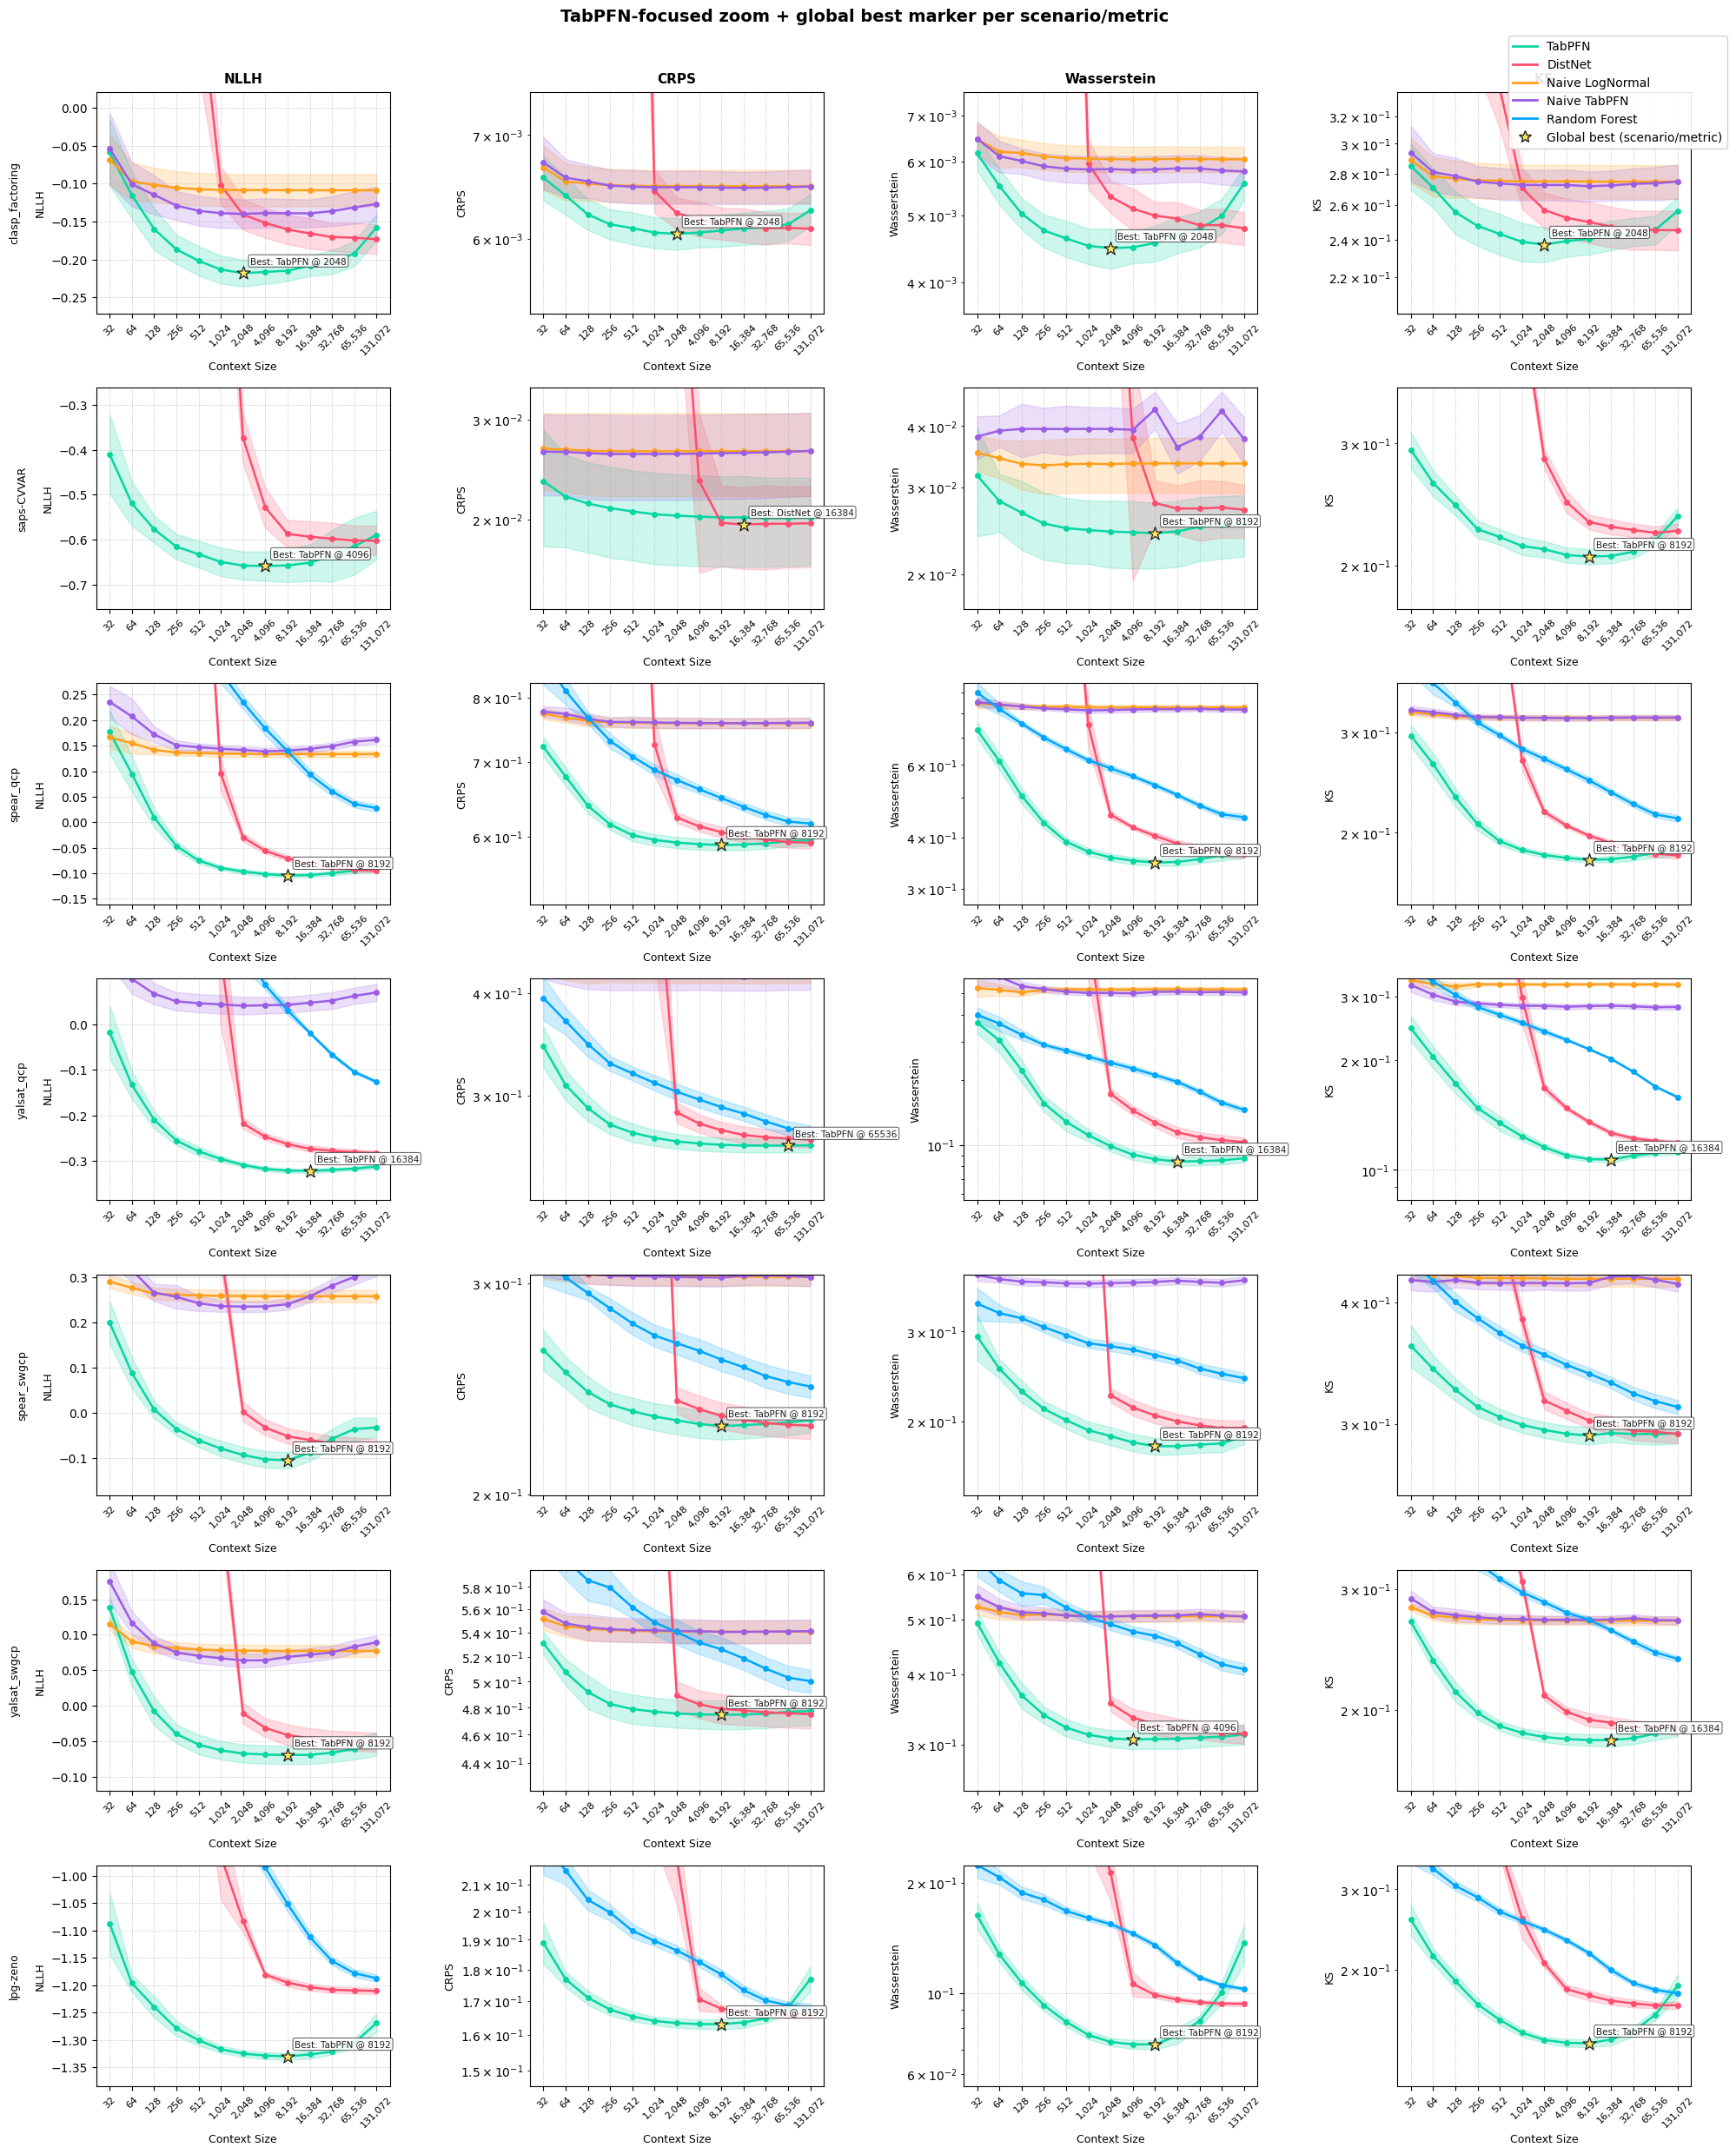

In [1]:
from collections import defaultdict
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tabpfn_project.paths import RESULTS_DIR
from tabpfn_project.globals import DISTNET_SCENARIOS

results_dir = RESULTS_DIR / "experiment_context_sizes"

with open(f"{results_dir}/tabpfn_all_scenarios.pkl", "rb") as f:
    tabpfn_default_results = pickle.load(f)

with open(f"{results_dir}/tabpfn_naive_all_scenarios.pkl", "rb") as f:
    tabpfn_naive_results = pickle.load(f)

with open(f"{results_dir}/distnet_all_scenarios.pkl", "rb") as f:
    distnet_results = pickle.load(f)

with open(f"{results_dir}/lognormal_naive_all_scenarios.pkl", "rb") as f:
    lognormal_naive_results = pickle.load(f)

with open(f"{results_dir}/random_forest_all_scenarios.pkl", "rb") as f:
    random_forest_results = pickle.load(f)

all_results = tabpfn_default_results + tabpfn_naive_results + distnet_results + random_forest_results + lognormal_naive_results

METRICS = ["NLLH", "CRPS", "Wasserstein", "KS"]

# ------------------------------------------------------------------
# Aggregation strategy requested:
# 1) For each (model, scenario, context_size, fold), average over seeds
# 2) For each (model, scenario, context_size), average over folds
# 3) Shade with std across folds
# ------------------------------------------------------------------

# (model, scenario, context_size, fold, metric) -> list of seed-level run scores
seed_scores_by_fold = defaultdict(list)

for entry in all_results:
    model = entry["model"]
    scenario = entry["scenario"]
    context_size = entry["context_size"]
    fold = entry["fold"]
    inst_summ = entry["instance_summary"]

    for metric in METRICS:
        vals = inst_summ[metric]
        if hasattr(vals, "cpu"):
            vals = vals.cpu().numpy()
        vals = np.asarray(vals).ravel()

        # One score per seed-run: mean over instances
        run_score = float(vals.mean())
        seed_scores_by_fold[(model, scenario, context_size, fold, metric)].append(run_score)

# (model, scenario, context_size, metric) -> list of fold means
fold_means = defaultdict(list)

for key, seed_scores in seed_scores_by_fold.items():
    model, scenario, context_size, fold, metric = key
    fold_mean = float(np.mean(seed_scores))
    fold_means[(model, scenario, context_size, metric)].append(fold_mean)

# Final plot data: mean/std over folds
plot_data = {}
for key, fold_scores in fold_means.items():
    scores = np.asarray(fold_scores, dtype=float)
    mean_over_folds = float(np.mean(scores))
    std_over_folds = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0
    plot_data[key] = (mean_over_folds, std_over_folds, len(scores))

# Keep all known scenarios visible (7 rows expected)
scenarios = list(DISTNET_SCENARIOS)
context_sizes = sorted({k[2] for k in plot_data.keys()})
models = ["tabpfn", "distnet", "lognormal_naive", "tabpfn_naive", "random_forest"]

print(f"Scenarios: {scenarios}")
print(f"Context sizes: {context_sizes}")
print(f"Models: {models}")
print(f"Total aggregated entries: {len(plot_data)}")

MODEL_COLORS = {
    "tabpfn": "#06D6A0",
    "distnet": "#FF4D6D",
    "random_forest": "#00A6FB",
    "tabpfn_naive": "#9B5DE5",
    "lognormal_naive": "#FF9F1C",
}
MODEL_LABELS = {"tabpfn": "TabPFN", "distnet": "DistNet", "random_forest": "Random Forest", "tabpfn_naive": "Naive TabPFN", "lognormal_naive": "Naive LogNormal"}
METRIC_LABELS = {"NLLH": "NLLH", "CRPS": "CRPS", "Wasserstein": "Wasserstein", "KS": "KS"}
LOG_METRICS = {"CRPS", "Wasserstein", "KS"}

n_rows = len(scenarios)
n_cols = len(METRICS)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 3.5 * n_rows),
    squeeze=False,
)

for row_idx, scenario in enumerate(scenarios):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx][col_idx]

        tabpfn_zoom_means = None
        tabpfn_zoom_stds = None

        for model in models:
            xs, means, stds = [], [], []
            for cs in context_sizes:
                key = (model, scenario, cs, metric)
                if key in plot_data:
                    m, s, n_folds = plot_data[key]
                    xs.append(cs)
                    means.append(m)
                    stds.append(s)

            if not xs:
                continue

            xs = np.array(xs, dtype=float)
            means = np.array(means, dtype=float)
            stds = np.array(stds, dtype=float)

            if model == "tabpfn":
                tabpfn_zoom_means = means.copy()
                tabpfn_zoom_stds = stds.copy()

            color = MODEL_COLORS[model]
            ax.plot(
                xs,
                means,
                marker="o",
                markersize=4,
                linewidth=1.8,
                color=color,
                label=MODEL_LABELS[model],
            )
            ax.fill_between(xs, means - stds, means + stds, alpha=0.20, color=color)

        ax.set_xscale("log", base=2)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        ax.set_xticks(context_sizes)
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)

        if metric in LOG_METRICS:
            ax.set_yscale("log")

        # Zoom each subplot to TabPFN behavior while keeping other models on the same axis.
        if tabpfn_zoom_means is not None and len(tabpfn_zoom_means) > 0:
            lower = tabpfn_zoom_means - tabpfn_zoom_stds
            upper = tabpfn_zoom_means + tabpfn_zoom_stds

            if metric in LOG_METRICS:
                lower = lower[lower > 0]
                upper = upper[upper > 0]
                if lower.size > 0 and upper.size > 0:
                    y_min = float(np.min(lower))
                    y_max = float(np.max(upper))
                    if y_max <= y_min:
                        y_max = y_min * 1.01
                    log_min = np.log10(y_min)
                    log_max = np.log10(y_max)
                    log_span = max(log_max - log_min, 1e-3)
                    pad_dec = 0.18 * log_span + 0.03
                    ax.set_ylim(10 ** (log_min - pad_dec), 10 ** (log_max + pad_dec))
            else:
                y_min = float(np.min(lower))
                y_max = float(np.max(upper))
                if y_max <= y_min:
                    ref = max(abs(y_min), 1.0)
                    y_min -= 0.01 * ref
                    y_max += 0.01 * ref
                span = y_max - y_min
                pad = 0.16 * span + 1e-10
                ax.set_ylim(y_min - pad, y_max + pad)

        # Best point among all models and all context sizes for this scenario/metric.
        candidate_points = []  # (score, context_size, model)
        for model in models:
            for cs in context_sizes:
                key = (model, scenario, cs, metric)
                if key in plot_data:
                    score = float(plot_data[key][0])
                    if metric in LOG_METRICS and score <= 0:
                        continue
                    candidate_points.append((score, cs, model))

        if candidate_points:
            best_score, best_cs, best_model = min(candidate_points, key=lambda t: (t[0], t[1]))
            y_low, y_high = ax.get_ylim()

            in_view = y_low <= best_score <= y_high
            if in_view:
                star_y = best_score
                label_suffix = ""
            else:
                if metric in LOG_METRICS:
                    star_y = y_high * 0.985 if best_score > y_high else y_low * 1.015
                else:
                    span = y_high - y_low
                    star_y = y_high - 0.02 * span if best_score > y_high else y_low + 0.02 * span
                label_suffix = " (off-scale)"

            ax.scatter(
                [best_cs],
                [star_y],
                marker="*",
                s=130,
                color="#FFE45E",
                edgecolors="#1f1f1f",
                linewidths=0.9,
                zorder=6,
                clip_on=False,
            )
            ax.annotate(
                f"Best: {MODEL_LABELS[best_model]} @ {int(best_cs)}{label_suffix}",
                xy=(best_cs, star_y),
                xytext=(6, 8),
                textcoords="offset points",
                fontsize=7.5,
                color="#1f1f1f",
                bbox={
                    "boxstyle": "round,pad=0.2",
                    "facecolor": "white",
                    "edgecolor": "#444444",
                    "alpha": 0.9,
                    "linewidth": 0.7,
                },
            )

        ax.set_xlabel("Context Size", fontsize=9)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)

        if row_idx == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold", pad=8)

        if col_idx == 0:
            ax.set_ylabel(
                f"{scenario}\n\n{METRIC_LABELS[metric]}",
                fontsize=9,
            )

        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)

# Shared legend
handles = [
    matplotlib.lines.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=2, label=MODEL_LABELS[m])
    for m in models
]
handles.append(
    matplotlib.lines.Line2D(
        [0],
        [0],
        marker="*",
        linestyle="None",
        markersize=10,
        markerfacecolor="#FFE45E",
        markeredgecolor="#1f1f1f",
        label="Global best (scenario/metric)",
    )
)
fig.legend(
    handles=handles,
    loc="upper right",
    fontsize=10,
    framealpha=0.9,
    bbox_to_anchor=(1.0, 1.0),
)

plt.suptitle(
    "TabPFN-focused zoom + global best marker per scenario/metric",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
from IPython.display import display

records = []
for (model, scenario, context_size, metric), (mean_over_folds, std_over_folds, n_folds) in plot_data.items():
    records.append(
        {
            "scenario": scenario,
            "metric": metric,
            "context_size": int(context_size),
            "model": model,
            "mean_over_folds": float(mean_over_folds),
            "std_over_folds": float(std_over_folds),
            "n_folds": int(n_folds),
        }
    )

results_df = pd.DataFrame(records)

# Keep the same ordering used in the plots.
scenario_order = list(scenarios) if "scenarios" in globals() else sorted(results_df["scenario"].unique())
metric_order = list(METRICS) if "METRICS" in globals() else sorted(results_df["metric"].unique())
model_order = list(models) if "models" in globals() else sorted(results_df["model"].unique())

results_df["scenario"] = pd.Categorical(results_df["scenario"], categories=scenario_order, ordered=True)
results_df["metric"] = pd.Categorical(results_df["metric"], categories=metric_order, ordered=True)
results_df["model"] = pd.Categorical(results_df["model"], categories=model_order, ordered=True)

results_df = results_df.sort_values(["scenario", "metric", "context_size", "model"]).reset_index(drop=True)
results_df[["mean_over_folds", "std_over_folds"]] = results_df[["mean_over_folds", "std_over_folds"]].round(3)

model_labels = {m: MODEL_LABELS.get(m, m) for m in model_order} if "MODEL_LABELS" in globals() else {m: m for m in model_order}

pretty_table = (
    results_df.assign(
        value=results_df["mean_over_folds"].map("{:.3f}".format)
        + " ± "
        + results_df["std_over_folds"].map("{:.3f}".format),
        model=results_df["model"].map(model_labels),
    )
    .pivot_table(
        index=["scenario", "metric", "context_size"],
        columns="model",
        values="value",
        aggfunc="first",
        sort=False,
        observed=False,
    )
    .reset_index()
    .rename(
        columns={
            "scenario": "Scenario",
            "metric": "Metric",
            "context_size": "Context Size",
        }
    )
)

display(pretty_table)

model,Scenario,Metric,Context Size,TabPFN,DistNet,Naive LogNormal,Naive TabPFN,Random Forest
0,clasp_factoring,NLLH,32,-0.059 ± 0.044,0.527 ± 0.046,-0.068 ± 0.033,-0.054 ± 0.047,1.664 ± 0.015
1,clasp_factoring,NLLH,64,-0.115 ± 0.031,0.524 ± 0.031,-0.097 ± 0.025,-0.101 ± 0.029,1.664 ± 0.015
2,clasp_factoring,NLLH,128,-0.160 ± 0.028,0.439 ± 0.040,-0.102 ± 0.023,-0.115 ± 0.026,1.664 ± 0.015
3,clasp_factoring,NLLH,256,-0.187 ± 0.019,0.309 ± 0.102,-0.106 ± 0.022,-0.129 ± 0.019,1.663 ± 0.015
4,clasp_factoring,NLLH,512,-0.202 ± 0.019,0.164 ± 0.115,-0.108 ± 0.021,-0.136 ± 0.020,1.663 ± 0.015
...,...,...,...,...,...,...,...,...
359,lpg-zeno,KS,8192,0.138 ± 0.003,0.176 ± 0.004,0.362 ± 0.007,0.363 ± 0.007,0.218 ± 0.003
360,lpg-zeno,KS,16384,0.141 ± 0.004,0.171 ± 0.004,0.362 ± 0.007,0.363 ± 0.007,0.200 ± 0.003
361,lpg-zeno,KS,32768,0.147 ± 0.004,0.169 ± 0.003,0.362 ± 0.007,0.364 ± 0.007,0.187 ± 0.002
362,lpg-zeno,KS,65536,0.160 ± 0.004,0.167 ± 0.002,0.362 ± 0.007,0.364 ± 0.007,0.181 ± 0.003
